###環境設定

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import warnings
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import os

# ==========================================
# 1. 屏蔽繪圖相關的擾人警告
# ==========================================
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas.plotting")

# ==========================================
# 2. 下載並設定 Noto Sans CJK TC (思源黑體)
# ==========================================
font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    print("   - 尚未找到字型，正在從 Google Fonts 下載...")
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
    print("   - 字型下載完成！")

# 註冊字型到 Matplotlib 的環境中
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False # 確保座標軸的負號正常顯示

print("✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。")

#掛載 Google Drive、設定輸出位置
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/AHP_outputs"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 已建立輸出資料夾: {OUTPUT_DIR}")

print("✅ 環境設定與套件載入完成！")

   - 尚未找到字型，正在從 Google Fonts 下載...
   - 字型下載完成！
✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。


ValueError: mount failed

# 📍 微觀道路廊道分析 - 步驟一：熱點全路網擷取與空間交集篩選

針對破碎的熱點村里分佈，為避免 OpenStreetMap API 遺漏資料，本步驟採用「大範圍包絡線下載 ➔ 精細空間交集篩選」之雙階段策略：
1. **大範圍下載**：利用熱點邊界的凸包 (Convex Hull) 向 OSM 請求全區域路網，避免複雜多邊形導致的 API 請求失敗。
2. **實體平面過濾**：使用自訂過濾器 (Custom Filter) 排除高架橋 (`bridge`)、地下道 (`tunnel`) 以及聯絡道 (`link`)，確保抓取真實可綠化的平面空間。
3. **精準交集 (Intersects)**：透過 `Spatial Join` 保留所有與熱點村里有「實體交集」之道路。此舉可確保跨越村里邊界的道路完整性，不因粗暴裁切而破碎。
4. **屬性清洗**：清理陣列 (List) 屬性並統一投影至 EPSG:3826，奠定後續緩衝區 (Buffer) 運算基礎。

In [ ]:
!pip install -q osmnx networkx geopandas shapely

import os
import geopandas as gpd
import osmnx as ox
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("🌐 重新啟動微觀廊道建構：使用凸包大範圍下載與 Sjoin 精準篩選...")

# ==========================================
# 1. 檔案路徑與熱點邊界設定
# ==========================================
MACRO_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
MICRO_DIR = "/content/drive/MyDrive/EPM_Final/Micro_outputs"
os.makedirs(MICRO_DIR, exist_ok=True)

hotspot_gpkg = os.path.join(MACRO_DIR, "Taipei_Vulnerability_Index.gpkg")
gdf_macro = gpd.read_file(hotspot_gpkg)
gdf_hotspots = gdf_macro[gdf_macro['Is_Hotspot'] == 1].copy()

if gdf_hotspots.crs.to_epsg() != 3826:
    gdf_hotspots = gdf_hotspots.to_crs(epsg=3826)

gdf_hotspots_4326 = gdf_hotspots.to_crs(epsg=4326)
hotspot_boundary = unary_union(gdf_hotspots_4326.geometry)
query_poly = hotspot_boundary.convex_hull

print(f"🎯 已鎖定熱點包絡範圍，準備向 OpenStreetMap 請求資料...")

# ==========================================
# 2. OSM 實體平面路網下載 (自訂過濾器)
# ==========================================
custom_filter = (
    '["highway"]'
    '["highway"!~"motorway|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link"]'
    '["bridge"!~"yes"]'
    '["tunnel"!~"yes"]'
)

print("⏳ 正在下載包絡線內所有平面街道，請稍候...")
G = ox.graph_from_polygon(query_poly, custom_filter=custom_filter, simplify=True)
_, gdf_edges = ox.graph_to_gdfs(G)

# ==========================================
# 3. 投影轉換、屬性清洗與空間交集 (sjoin)
# ==========================================
print("🧹 正在進行投影轉換與 Spatial Join 篩選...")
gdf_edges_3826 = gdf_edges.to_crs(epsg=3826)

# ★ 修正核心 1：先清理 OSM 資料中惱人的 list 格式 (轉為字串)，避免 drop_duplicates 報錯
for col in gdf_edges_3826.columns:
    if gdf_edges_3826[col].apply(lambda x: isinstance(x, list)).any():
        gdf_edges_3826[col] = gdf_edges_3826[col].astype(str)

# 只保留有「摸到 (intersects)」熱點村里的道路，且保留完整線段
gdf_edges_hotspot = gpd.sjoin(
    gdf_edges_3826,
    gdf_hotspots[['TOWNNAME', 'VILLNAME', 'geometry']],
    how='inner',
    predicate='intersects'
)

# ★ 修正核心 2：在 list 被轉成字串後，安全地執行去重複
gdf_edges_hotspot = gdf_edges_hotspot.drop_duplicates(subset=['osmid', 'geometry'])

# 重設 Index 賦予乾淨的 ID
gdf_edges_clean = gdf_edges_hotspot.reset_index(drop=True)
gdf_edges_clean['OSM_Street_ID'] = gdf_edges_clean.index.astype(str)

print(f"✅ 篩選完成！共精準萃取出 {len(gdf_edges_clean)} 條經過熱點的完整道路線段。")

# ==========================================
# 4. 繪圖檢核與存檔
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10))
gdf_hotspots.plot(ax=ax, color='#e0e0e0', edgecolor='white', alpha=0.8)
gdf_edges_clean.plot(ax=ax, color='#1f77b4', linewidth=1)
ax.set_title("修正後：熱點區域實體平面路徑 (完整交集擷取)", fontsize=15, fontweight='bold')
ax.axis('off')
plt.show()

output_raw_streets = os.path.join(MICRO_DIR, "Hotspot_Raw_Streets.gpkg")
gdf_edges_clean.to_file(output_raw_streets, driver="GPKG")
print(f"📦 完整交集萃取之熱點路網已儲存至: {output_raw_streets}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.6 MB/s eta 0:00:00
🌐 重新啟動微觀廊道建構：使用凸包大範圍下載與 Sjoin 精準篩選...


DataSourceError: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg: No such file or directory

# 📍 微觀道路廊道分析 - 終極版步驟二：主從拓撲吸收與動態緩衝生成

實踐「大幹道為主，小路/步道為輔」的空間吸附邏輯，藉此估算真實的街道腹地與空間餘裕 (Space Margin)。
1. **主從分類**：將路網拆分為「大幹道 (Major)」與「其他道路 (Others，含巷弄與慢行道)」。
2. **偵測與吸附 (Spatial Intersection)**：大幹道向外擴張形成「雷達區」。若「其他道路」落在雷達區內，則將其視為附屬設施，並將該屬性 (`has_footway`, `has_cycleway`) 轉移給大幹道，藉此動態增加大幹道的實體緩衝區寬度。
3. **獨立生成與合併**：完全獨立的巷弄或步道將賦予其專屬微型緩衝區，最後與吸附後的大幹道合併，形成完整的「分析廊道 (Analytical Corridors)」。

📐 正在針對熱點路網執行主從空間吸附與動態緩衝生成...
🔍 正在以「動態超大範圍」掃描大幹道周邊附屬設施...
🚧 正在產出高對比檢核地圖...


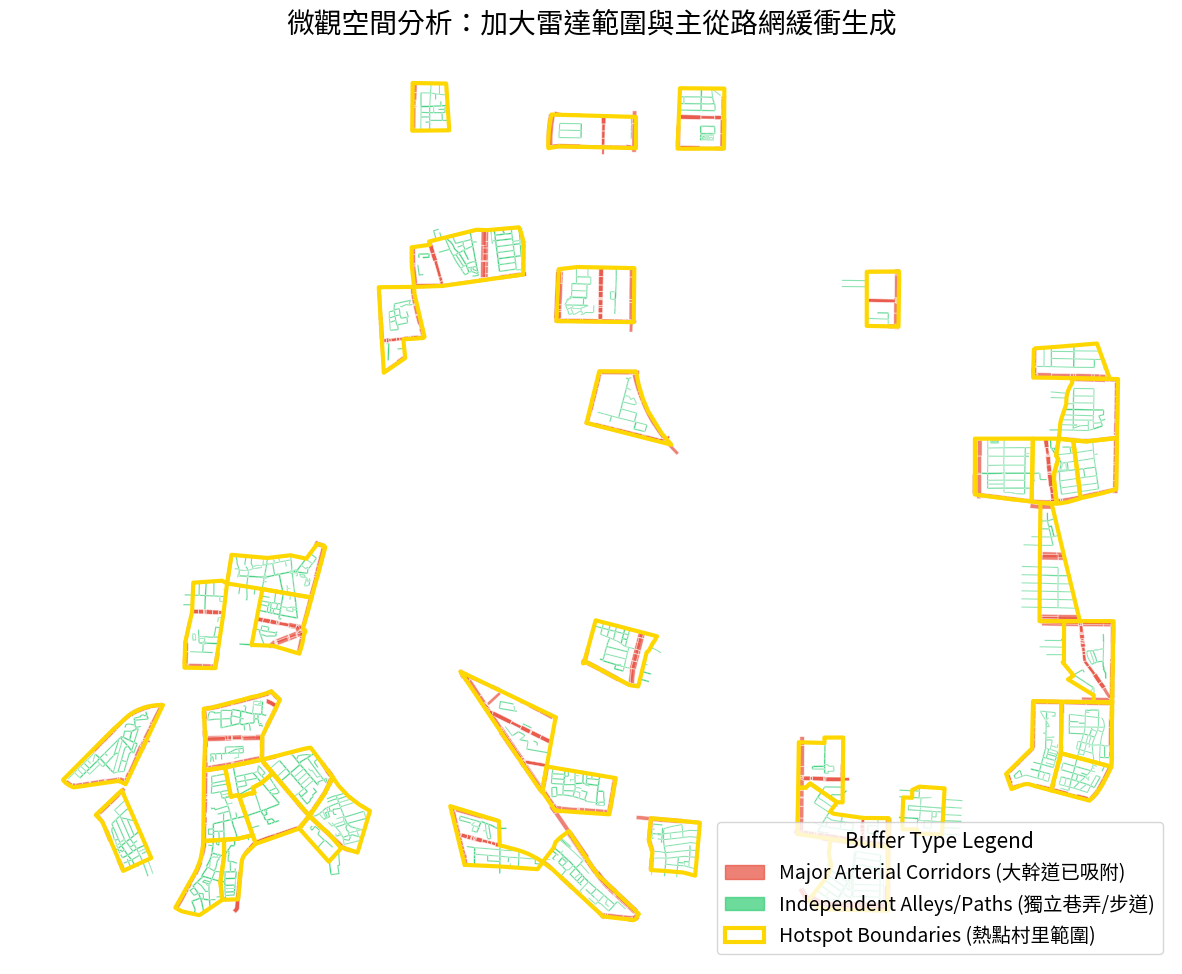

✅ 治本修正完成！具備屬性之緩衝路廊已存至: /content/drive/MyDrive/EPM_Final/Micro_outputs/Hotspot_Buffered_Streets.gpkg

👀 最終緩衝路廊前 5 筆屬性資料 (包含路寬、緩衝半徑等)：


,OSM_Street_ID,highway,est_width,has_footway,has_cycleway,extra_buf,corridor_radius
0,0,secondary,12.0,True,True,10.0,16.0
1,1,tertiary,8.0,False,True,6.0,10.0
2,2,tertiary,8.0,True,False,10.0,14.0
3,3,primary,15.0,True,False,10.0,17.5
4,5,tertiary,8.0,False,False,3.0,7.0


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import re
import warnings
warnings.filterwarnings('ignore')

print("📐 正在針對熱點路網執行主從空間吸附與動態緩衝生成...")

# 讀取剛剛步驟一產出的乾淨線段
MICRO_DIR = "/content/drive/MyDrive/EPM_Final/Micro_outputs"
input_raw_streets = os.path.join(MICRO_DIR, "Hotspot_Raw_Streets.gpkg")
edges_all_twd97 = gpd.read_file(input_raw_streets)

# 清除上一次 sjoin 殘留下來的 index_right / index_left 欄位，避免衝突
edges_all_twd97 = edges_all_twd97.drop(columns=['index_right', 'index_left'], errors='ignore')

MACRO_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
hotspot_gpkg = os.path.join(MACRO_DIR, "Taipei_Vulnerability_Index.gpkg")
gdf_macro = gpd.read_file(hotspot_gpkg)
gdf_hotspots = gdf_macro[gdf_macro['Is_Hotspot'] == 1].to_crs(epsg=3826)

# ==========================================
# 1. 建立路寬推估邏輯與分類 (導入 Regex 精準萃取數字)
# ==========================================
WIDTH_MAP = {
    'primary': 15, 'secondary': 12, 'tertiary': 8,
    'residential': 6, 'living_street': 5, 'service': 4, 'unclassified': 4,
    'footway': 2, 'cycleway': 2, 'pedestrian': 3, 'path': 2
}

def estimate_width(row):
    if 'width' in row and pd.notnull(row['width']) and str(row['width']) not in ['nan', 'None']:
        try:
            # 利用正規表達式找出字串中的第一個數字 (例如 "['10', '12']" -> 10.0, "15 m" -> 15.0)
            nums = re.findall(r"\d+\.?\d*", str(row['width']))
            if nums:
                return float(nums[0])
        except: pass
    return WIDTH_MAP.get(row['highway'], 4)

edges_all_twd97['est_width'] = edges_all_twd97.apply(estimate_width, axis=1)

major_types = ['primary', 'secondary', 'tertiary']
edges_major = edges_all_twd97[edges_all_twd97['highway'].isin(major_types)].copy()
edges_other = edges_all_twd97[~edges_all_twd97['highway'].isin(major_types)].copy()

edges_major['major_id'] = range(len(edges_major))
edges_other['other_id'] = range(len(edges_other))

# ==========================================
# 2. 建立大幹道雷達區 (稍微加大容錯半徑確保完全吸附)
# ==========================================
def get_radar_extra(hw):
    if hw == 'primary': return 15.0
    if hw == 'secondary': return 12.0
    return 10.0

edges_major['radar_extra'] = edges_major['highway'].apply(get_radar_extra)
search_gdf = edges_major[['major_id', 'geometry']].copy()
# 生成超大雷達區
search_gdf['geometry'] = search_gdf.geometry.buffer((edges_major['est_width']/2) + edges_major['radar_extra'], cap_style=2)

print("🔍 正在以「動態超大範圍」掃描大幹道周邊附屬設施...")
covered_join = gpd.sjoin(edges_other, search_gdf, how='inner', predicate='intersects')

# ==========================================
# 3. 處理「被吸附」的道路 ➔ 記錄並加寬
# ==========================================
covered_types = covered_join.groupby('major_id')['highway'].apply(list).reset_index()

def calc_extra_buf(types_list):
    extra = 3.0
    if any(t in types_list for t in ['footway', 'pedestrian', 'path']): extra += 4.0
    if 'cycleway' in types_list: extra += 3.0
    if any(t in types_list for t in ['residential', 'service', 'living_street', 'unclassified']): extra += 3.0
    return extra

covered_types['extra_buf'] = covered_types['highway'].apply(calc_extra_buf)
covered_types['has_footway'] = covered_types['highway'].apply(lambda x: any(t in x for t in ['footway', 'pedestrian', 'path']))
covered_types['has_cycleway'] = covered_types['highway'].apply(lambda x: 'cycleway' in x)

edges_major = edges_major.merge(covered_types[['major_id', 'extra_buf', 'has_footway', 'has_cycleway']], on='major_id', how='left')

edges_major['extra_buf'] = edges_major['extra_buf'].fillna(3.0)
edges_major['has_footway'] = edges_major['has_footway'].fillna(False)
edges_major['has_cycleway'] = edges_major['has_cycleway'].fillna(False)

edges_major['corridor_radius'] = (edges_major['est_width']/2) + edges_major['extra_buf']
edges_major['initial_buffer'] = edges_major.geometry.buffer(edges_major['corridor_radius'], cap_style=2)

# ==========================================
# 4. 處理「未被覆蓋 (獨立)」的道路
# ==========================================
independent_others = edges_other[~edges_other['other_id'].isin(covered_join['other_id'])].copy()

independent_others['has_footway'] = independent_others['highway'].isin(['footway', 'pedestrian', 'path'])
independent_others['has_cycleway'] = independent_others['highway'] == 'cycleway'
independent_others['corridor_radius'] = (independent_others['est_width']/2) + 1.5
independent_others['initial_buffer'] = independent_others.geometry.buffer(independent_others['corridor_radius'], cap_style=2)

# ==========================================
# 5. 合併兩者並輸出高對比地圖 (★ 加上自訂圖例)
# ==========================================
print("🚧 正在產出高對比檢核地圖...")
final_corridors = pd.concat([
    edges_major.set_geometry('initial_buffer'),
    independent_others.set_geometry('initial_buffer')
], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 15))

# 畫大幹道與獨立道路
final_corridors[final_corridors['highway'].isin(major_types)].plot(
    ax=ax, color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.5, zorder=2
)
final_corridors[~final_corridors['highway'].isin(major_types)].plot(
    ax=ax, color='#2ecc71', alpha=0.7, edgecolor='white', linewidth=0.3, zorder=1
)
# 畫熱點邊界
gdf_hotspots.plot(ax=ax, facecolor='none', edgecolor='#FFD700', linewidth=3, zorder=5)

# 建構自訂圖例
red_patch = mpatches.Patch(color='#e74c3c', alpha=0.7, label='Major Arterial Corridors (大幹道已吸附)')
green_patch = mpatches.Patch(color='#2ecc71', alpha=0.7, label='Independent Alleys/Paths (獨立巷弄/步道)')
yellow_patch = mpatches.Patch(facecolor='none', edgecolor='#FFD700', linewidth=3, label='Hotspot Boundaries (熱點村里範圍)')
ax.legend(handles=[red_patch, green_patch, yellow_patch], fontsize=14, loc='lower right', title='Buffer Type Legend', title_fontsize=15)

ax.set_title("微觀空間分析：加大雷達範圍與主從路網緩衝生成", fontsize=20, fontweight='bold')
ax.axis('off')
plt.show()

# ==========================================
# 6. 處理幾何衝突並存檔
# ==========================================
output_buffered_streets = os.path.join(MICRO_DIR, "Hotspot_Buffered_Streets.gpkg")

export_gdf = final_corridors.set_geometry('initial_buffer')
export_gdf = export_gdf.drop(columns=['geometry'], errors='ignore')
export_gdf = export_gdf.rename_geometry('geometry')

export_gdf = export_gdf.drop(columns=['major_id', 'other_id', 'index_right', 'index_left'], errors='ignore')
for col in export_gdf.columns:
    if export_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        export_gdf[col] = export_gdf[col].astype(str)

export_gdf.to_file(output_buffered_streets, driver="GPKG")
print(f"✅ 治本修正完成！具備屬性之緩衝路廊已存至: {output_buffered_streets}")

# ==========================================
# 7. 預覽前五筆路段 polygon 的寬度等關鍵資訊
# ==========================================
print("\n👀 最終緩衝路廊前 5 筆屬性資料 (包含路寬、緩衝半徑等)：")
display_cols = ['OSM_Street_ID', 'highway', 'est_width', 'has_footway', 'has_cycleway', 'extra_buf', 'corridor_radius']
cols_to_show = [c for c in display_cols if c in export_gdf.columns]
display(export_gdf[cols_to_show].head())

# 📍 微觀階段 3：實體建物空間疊合與路廊覆蓋率 (Building Ratio) 計算

本步驟放棄傳統破壞性的幾何裁切，改採**「空間疊合 (Spatial Overlay)」**工程，將兩側建物轉化為環境限制指標：
1. **完整路廊載入**：讀取步驟二產出之完整、未裁切的動態緩衝路廊 (`Hotspot_Buffered_Streets.gpkg`)。
2. **建物相交面積計算**：利用 `gpd.overlay` 計算每個路廊多邊形與台北市 3D 建物框重疊的實體面積。
3. **建構結構密度指標 (Bui_Ratio)**：計算 `建物重疊面積 / 路廊總面積`，數值介於 0~1 之間。數值越高，代表該街道受建物包夾越嚴重（街谷效應強、灰色基盤密度高），在 TOPSIS 模型中將作為「需要綠化資源投入」的正向推力。

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

print("🏠 正在啟動微觀階段 3：計算建物佔路廊之面積比例...")

# ==========================================
# 1. 圖資載入 (讀取步驟二未裁切的完整緩衝路廊)
# ==========================================
MICRO_DIR = "/content/drive/MyDrive/EPM_Final/Micro_outputs"
input_buffered_streets = os.path.join(MICRO_DIR, "Hotspot_Buffered_Streets.gpkg")
gdf_corridors = gpd.read_file(input_buffered_streets)

# 讀取熱點村里邊界 (用作建物載入的遮罩)
MACRO_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
hotspot_gpkg = os.path.join(MACRO_DIR, "Taipei_Vulnerability_Index.gpkg")
gdf_hotspots = gpd.read_file(hotspot_gpkg).to_crs(epsg=3826)
gdf_hotspots_hot = gdf_hotspots[gdf_hotspots['Is_Hotspot'] == 1]

# 讀取 3D 建物框
bui_shp_path = "/content/drive/MyDrive/GIS_data/台北市3D建物框/A_1133BUIE.shp"
print("   -> 正在載入熱點邊界範圍內的實體建物...")
gdf_buildings = gpd.read_file(bui_shp_path, mask=gdf_hotspots_hot)
gdf_buildings = gdf_buildings.to_crs(epsg=3826)

# ==========================================
# 2. 空間疊合與面積比率計算
# ==========================================
print("⏳ 正在執行幾何疊合運算 (Intersection Overlay)...")
# 計算每個路廊原始的總面積 (平方公尺)
gdf_corridors['Total_Area'] = gdf_corridors.geometry.area

# 找出路廊與建物重疊的幾何交集
bui_intersect = gpd.overlay(
    gdf_corridors[['OSM_Street_ID', 'geometry']],
    gdf_buildings[['geometry']],
    how='intersection'
)

# 計算重疊部分的建築面積
bui_intersect['Bui_Area'] = bui_intersect.geometry.area

# 依照街道 ID 加總重疊的建物面積
bui_area_sum = bui_intersect.groupby('OSM_Street_ID')['Bui_Area'].sum().reset_index()

# 將重疊建物面積接回主路廊表
gdf_corridors = gdf_corridors.merge(bui_area_sum, on='OSM_Street_ID', how='left')
gdf_corridors['Bui_Area'] = gdf_corridors['Bui_Area'].fillna(0.0)

# 計算建物佔路廊面積比例 (限制在 0~1 之間，防呆取 max 1.0)
gdf_corridors['Bui_Ratio'] = round(gdf_corridors['Bui_Area'] / gdf_corridors['Total_Area'], 4)
gdf_corridors['Bui_Ratio'] = gdf_corridors['Bui_Ratio'].clip(upper=1.0)

print("✅ 建物覆蓋比例計算完成！")

# ==========================================
# 3. 成果檢視與存檔
# ==========================================
print("\n👀 建物覆蓋比例 (Bui_Ratio) 前 5 筆成果預覽：")
display(gdf_corridors[['OSM_Street_ID', 'highway', 'est_width', 'Total_Area', 'Bui_Area', 'Bui_Ratio']].head())

# 存檔至新圖層
output_bui_ratio_gpkg = os.path.join(MICRO_DIR, "Hotspot_Corridors_With_Bui.gpkg")
gdf_corridors.to_file(output_bui_ratio_gpkg, driver="GPKG")
print(f"📦 帶有建物比例參數的路廊圖資已儲存至: {output_bui_ratio_gpkg}")

🏠 正在啟動微觀階段 3：計算建物佔路廊之面積比例...
   -> 正在載入熱點邊界範圍內的實體建物...
⏳ 正在執行幾何疊合運算 (Intersection Overlay)...
✅ 建物覆蓋比例計算完成！

👀 建物覆蓋比例 (Bui_Ratio) 前 5 筆成果預覽：


,OSM_Street_ID,highway,est_width,Total_Area,Bui_Area,Bui_Ratio
0,0,secondary,12.0,191.756059,0.000000,0.0000
1,1,tertiary,8.0,520.227492,0.000000,0.0000
2,2,tertiary,8.0,304.571056,37.968166,0.1247
3,3,primary,15.0,257.718010,60.264336,0.2338
4,5,tertiary,8.0,170.029202,0.000000,0.0000


📦 帶有建物比例參數的路廊圖資已儲存至: /content/drive/MyDrive/EPM_Final/Micro_outputs/Hotspot_Corridors_With_Bui.gpkg


# 📍 微觀階段 4：決策變數空間建構 - 街樹生態指標與 NDVI 截斷萃取

本步驟在保留完整物理邊界的廊道內，進行多來源數據的空間對齊與環境指標計算：
1. **樹胸圍至胸徑轉換 (DBH)**：針對清冊提供的「樹胸圍 (Circumference)」，依圓周率公式轉換為標準胸徑：$DBH = (樹胸圍 / \pi) / 100$ (公尺)。
2. **香農多樣性與固碳量**：依據路廊內實際截獲的樹種分布計算香農指數，並透過材積公式推估現有地上固碳主體（kg）。
3. **座標自動對齊與 NDVI 截斷處理**：為解決影像與向量圖層座標不匹配導致的空值問題，程式將自動偵測 NDVI TIF 檔的 CRS 並進行即時投影轉換。同時，針對都市硬體鋪面或建物陰影所產生的 NDVI 負值，**統一截斷歸零 (Clip to 0)**，使其符合決策模型中「綠色植被存在度」之實質物理意義。

In [ ]:
!pip install -q rasterstats rasterio

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import warnings
warnings.filterwarnings('ignore')

print("🌳 正在啟動微觀變數建構：街樹生態指標與 NDVI 截斷運算...")

# ==========================================
# 1. 檔案路徑載入與幾何防呆清理
# ==========================================
MICRO_DIR = "/content/drive/MyDrive/EPM_Final/Micro_outputs"
input_bui_ratio_gpkg = os.path.join(MICRO_DIR, "Hotspot_Corridors_With_Bui.gpkg")
tree_csv_path = "/content/drive/MyDrive/EPM_Final/樹木清冊/台北市公園處&街樹完整_清理後.csv"
ndvi_tif_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDVI_2025_10m.tif"

gdf_corridors = gpd.read_file(input_bui_ratio_gpkg)
gdf_corridors = gdf_corridors[gdf_corridors.geometry.notna() & ~gdf_corridors.geometry.is_empty].copy()
gdf_corridors = gdf_corridors.reset_index(drop=True)

# ==========================================
# 2. 載入並建立樹木點圖資 (確保 CRS 對齊)
# ==========================================
df_trees = pd.read_csv(tree_csv_path, low_memory=False)
gdf_trees = gpd.GeoDataFrame(
    df_trees,
    geometry=gpd.points_from_xy(df_trees['TWD97X座標'], df_trees['TWD97Y座標']),
    crs="EPSG:3826"
)

# ==========================================
# 3. 欄位動態對應與數值清理
# ==========================================
def find_col(possible_names, df_cols):
    for name in possible_names:
        for col in df_cols:
            if name in col: return col
    return None

h_col = find_col(['樹高', 'HEIGHT', 'Height'], df_trees.columns) or '樹高'
c_col = find_col(['樹胸圍', '胸圍', 'Girth', 'Circumference'], df_trees.columns) or '樹胸圍'
s_col = find_col(['樹種名稱', '樹種', 'SPECIES'], df_trees.columns) or '樹種名稱'

gdf_trees[h_col] = pd.to_numeric(gdf_trees[h_col], errors='coerce').fillna(5.0)
gdf_trees[c_col] = pd.to_numeric(gdf_trees[c_col], errors='coerce').fillna(47.1) # 預設胸圍
gdf_trees[s_col] = gdf_trees[s_col].astype(str).fillna('未知樹種')

# ==========================================
# 4. 空間點對聚 (Spatial Join) 與生態指標計算
# ==========================================
print("⏳ 正在執行街樹空間點對聚並計算生態多樣性與固碳量...")
gdf_corridors['temp_id'] = gdf_corridors.index
trees_in_corridor = gpd.sjoin(gdf_trees, gdf_corridors[['temp_id', 'geometry']], how='inner', predicate='intersects')

print(f"🎯 偵錯報告：共有 {len(trees_in_corridor)} 棵樹成功落入熱點緩衝路廊內！")

street_metrics = {}
for temp_id, group in trees_in_corridor.groupby('temp_id'):
    tree_count = len(group)

    # 計算香農多樣性
    species_counts = group[s_col].value_counts()
    probs = species_counts / tree_count
    shannon_idx = -round(np.sum(probs * np.log(probs + 1e-9)), 4)

    # 🌟 核心修正：利用樹胸圍 (c_col) 計算胸徑 (DBH)
    dbh_m = (group[c_col] / np.pi) / 100.0
    height_m = group[h_col]

    # 台灣常規闊葉樹材積與固碳換算 (形數 0.45 * 基本碳儲存率 500)
    carbon_seq_kg = np.sum((np.pi / 4) * (dbh_m**2) * height_m * 0.45 * 500)

    street_metrics[temp_id] = {
        'Tree_Count': tree_count,
        'Shannon_Index': shannon_idx,
        'Carbon_Sequestration': round(carbon_seq_kg, 2)
    }

# 回填屬性
gdf_corridors['Tree_Count'] = gdf_corridors['temp_id'].map(lambda x: street_metrics.get(x, {}).get('Tree_Count', 0))
gdf_corridors['Shannon_Index'] = gdf_corridors['temp_id'].map(lambda x: street_metrics.get(x, {}).get('Shannon_Index', 0.0))
gdf_corridors['Carbon_Sequestration'] = gdf_corridors['temp_id'].map(lambda x: street_metrics.get(x, {}).get('Carbon_Sequestration', 0.0))

# 計算街樹密度 (棵/km)
if 'length' not in gdf_corridors.columns:
    gdf_corridors['length'] = gdf_corridors.geometry.length
gdf_corridors['length_km'] = gdf_corridors['length'] / 1000.0
gdf_corridors['Tree_Density'] = np.where(gdf_corridors['length_km'] > 0, round(gdf_corridors['Tree_Count'] / gdf_corridors['length_km'], 2), 0)

# ==========================================
# 5. 萃取衛星 NDVI 指數 (座標對齊 + 負值截斷)
# ==========================================
print("🌿 正在讀取衛星影像資訊並對齊座標系統...")
with rasterio.open(ndvi_tif_path) as src:
    raster_crs = src.crs

# 將路廊投影至 TIF 的座標系統進行精準計算
gdf_corridors_for_ndvi = gdf_corridors.to_crs(raster_crs)

print("⏳ 正在分區統計萃取平均 NDVI 數值...")
stats = zonal_stats(gdf_corridors_for_ndvi, ndvi_tif_path, stats="mean", nodata=np.nan, geojson_out=False)

# 寫回主要屬性表
gdf_corridors['NDVI_mean'] = [s['mean'] for s in stats]
gdf_corridors['NDVI_mean'] = gdf_corridors['NDVI_mean'].fillna(0.0)

# 🌟 核心修正：將陰影或硬體鋪面造成的 NDVI 負值直接截斷歸零 (Clamp to 0)
gdf_corridors['NDVI_mean'] = gdf_corridors['NDVI_mean'].clip(lower=0.0)

# 清理暫存欄位
gdf_corridors = gdf_corridors.drop(columns=['temp_id', 'length_km'])

print("\n✅ 指標運算完畢！最新微觀變數矩陣預覽：")
display_cols = ['OSM_Street_ID', 'highway', 'Bui_Ratio', 'Tree_Count', 'Tree_Density', 'Shannon_Index', 'Carbon_Sequestration', 'NDVI_mean']
display(gdf_corridors[display_cols].head(10))

# 圖資最終封裝
output_final_matrix_gpkg = os.path.join(MICRO_DIR, "Taipei_Micro_Decision_Matrix.gpkg")
gdf_corridors.to_file(output_final_matrix_gpkg, driver="GPKG")
print(f"\n📦 【微觀多準則基礎矩陣】已成功儲存至: {output_final_matrix_gpkg}")

🌳 正在啟動微觀變數建構：街樹生態指標與 NDVI 截斷運算...
⏳ 正在執行街樹空間點對聚並計算生態多樣性與固碳量...
🎯 偵錯報告：共有 6846 棵樹成功落入熱點緩衝路廊內！
🌿 正在讀取衛星影像資訊並對齊座標系統...
⏳ 正在分區統計萃取平均 NDVI 數值...

✅ 指標運算完畢！最新微觀變數矩陣預覽：


,OSM_Street_ID,highway,Bui_Ratio,Tree_Count,Tree_Density,Shannon_Index,Carbon_Sequestration,NDVI_mean
0,0,secondary,0.0000,0,0.0,0.0,0.0,0.095525
1,1,tertiary,0.0000,0,0.0,0.0,0.0,0.049696
2,2,tertiary,0.1247,0,0.0,0.0,0.0,0.019050
3,3,primary,0.2338,0,0.0,0.0,0.0,0.022437
4,5,tertiary,0.0000,0,0.0,0.0,0.0,0.017537
5,6,secondary,0.0000,0,0.0,0.0,0.0,0.002144
6,7,tertiary,0.0000,0,0.0,0.0,0.0,0.007589
7,8,tertiary,0.0255,0,0.0,0.0,0.0,0.000000
8,9,secondary,0.0018,0,0.0,0.0,0.0,0.000000
9,10,tertiary,0.0000,0,0.0,0.0,0.0,0.007589



📦 【微觀多準則基礎矩陣】已成功儲存至: /content/drive/MyDrive/EPM_Final/Micro_outputs/Taipei_Micro_Decision_Matrix.gpkg


# 📍 微觀階段 5：決策矩陣封裝確認與互動式 QA/QC 地圖

在進入 Fuzzy-AHP 權重分配與 TOPSIS 排序之前，本步驟旨在進行空間資料的品質管理 (Quality Assurance / Quality Control)：
1. **圖資讀取確認**：讀取上一階段已封裝的微觀多準則基礎矩陣 (`Taipei_Micro_Decision_Matrix.gpkg`)，確認檔案已成功儲存至雲端硬碟，以利後續的決策模型 Colab 筆記本讀取。
2. **互動式視覺化**：透過 `leafmap` 套件，將路廊多邊形與現有街樹點位疊加。
3. **動態資訊檢視**：使用者可透過圖層控制器開關圖層，並將鼠標懸停於各街道段上，即時檢視 `Bui_Ratio` (建物比例)、`NDVI_mean` (綠覆)、`NDBI_mean` (不透水層) 與各項街樹生態指標，確保空間對位與數值計算正確無誤。

In [ ]:
!pip install -q leafmap

import leafmap.foliumap as leafmap
import geopandas as gpd
import pandas as pd
import os

print("🗺️ 正在建置高效能獨立網頁查核地圖...")

# ==========================================
# 1. 讀取微觀決策矩陣 (確保從雲端硬碟讀取)
# ==========================================
MICRO_DIR = "/content/drive/MyDrive/EPM_Final/Micro_outputs"
input_matrix_path = os.path.join(MICRO_DIR, "Taipei_Micro_Decision_Matrix.gpkg")

if not os.path.exists(input_matrix_path):
    print(f"⚠️ 錯誤：找不到檔案 {input_matrix_path}，請確認微觀階段 4 已成功執行！")
else:
    print(f"📦 成功讀取最終決策圖資：{input_matrix_path}")

    # Folium 互動地圖必須使用 WGS84 (EPSG:4326) 座標系統
    gdf_streets = gpd.read_file(input_matrix_path).to_crs(epsg=4326)

    # 挑選要在地圖上滑鼠懸停顯示的核心變數 (已排除公園距離，保留最新的 NDBI_mean)
    hover_cols = ['OSM_Street_ID', 'highway', 'Bui_Ratio', 'Tree_Density', 'Shannon_Index', 'Carbon_Sequestration', 'NDVI_mean', 'NDBI_mean']
    existing_hover_cols = [col for col in hover_cols if col in gdf_streets.columns]

    # ==========================================
    # 2. 讀取樹木點位 (用於疊圖驗證)
    # ==========================================
    tree_csv_path = "/content/drive/MyDrive/EPM_Final/樹木清冊/台北市公園處&街樹完整_清理後.csv"
    print("🌳 正在載入樹木清冊以供空間視覺驗證...")
    df_trees = pd.read_csv(tree_csv_path, low_memory=False)
    gdf_trees_check = gpd.GeoDataFrame(
        df_trees,
        geometry=gpd.points_from_xy(df_trees['TWD97X座標'], df_trees['TWD97Y座標']),
        crs="EPSG:3826"
    ).to_crs(epsg=4326)

    # 為了地圖效能，僅保留與熱點路廊範圍包絡線有交集的樹木點
    bounds = gdf_streets.unary_union.bounds # (minx, miny, maxx, maxy)
    gdf_trees_check = gdf_trees_check.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

    # ==========================================
    # 3. 建置 Leafmap 基礎地圖物件
    # ==========================================
    # 以所有街道的中心點作為地圖初始中心
    center_y = gdf_streets.geometry.centroid.y.mean()
    center_x = gdf_streets.geometry.centroid.x.mean()
    m = leafmap.Map(center=[center_y, center_x], zoom=14)

    # A. 添加熱點街道路廊 (設定滑鼠懸停提示)
    m.add_gdf(
        gdf_streets,
        layer_name='微觀街道路廊 (滑鼠懸停看數值)',
        info_mode='hover',
        fields=existing_hover_cols,
        style={'color': '#3498db', 'fillOpacity': 0.5, 'weight': 2},
        hover_style={'fillOpacity': 0.9, 'color': '#f39c12'}
    )

    # B. 添加現有街樹點 (綠色圓點)
    m.add_gdf(
        gdf_trees_check,
        layer_name='現有樹木點 (驗證用)',
        style={'radius': 3, 'color': '#2ecc71', 'fillOpacity': 0.9},
        zoom_to_layer=False
    )

    # 添加圖層切換控制 (位於地圖右上角)
    m.add_layer_control()

    # ==========================================
    # 4. ★ 核心修正：將地圖物件封裝並保存為獨立網頁 HTML
    # ==========================================
    output_html_path = os.path.join(MICRO_DIR, "Taipei_Micro_Check_Map.html")

    # 呼叫 leafmap 的 HTML 導出函數
    m.to_html(filepath=output_html_path)

    print("\n網頁打包封裝成功！")
    print(f"💾 互動式查核地圖網頁已成功存至：{output_html_path}")
    print("👉 小組查核操作說明：")
    print("   1. 請至 Google Drive 雲端硬碟的 `Micro_outputs` 資料夾。")
    print("   2. 將 `Taipei_Micro_Check_Map.html` 下載至你的個人本機電腦。")
    print("   3. 雙擊該網頁檔案打開（會直接以網頁瀏覽器開啟），即可享受全螢幕、零延遲的流暢互動查核體驗！")

🗺️ 正在建置高效能獨立網頁查核地圖...
📦 成功讀取最終決策圖資：/content/drive/MyDrive/EPM_Final/Micro_outputs/Taipei_Micro_Decision_Matrix.gpkg
🌳 正在載入樹木清冊以供空間視覺驗證...

網頁打包封裝成功！
💾 互動式查核地圖網頁已成功存至：/content/drive/MyDrive/EPM_Final/Micro_outputs/Taipei_Micro_Check_Map.html
👉 小組查核操作說明：
   1. 請至 Google Drive 雲端硬碟的 `Micro_outputs` 資料夾。
   2. 將 `Taipei_Micro_Check_Map.html` 下載至你的個人本機電腦。
   3. 雙擊該網頁檔案打開（會直接以網頁瀏覽器開啟），即可享受全螢幕、零延遲的流暢互動查核體驗！
